In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import seaborn as sns
import networkx as nx


import pingouin as pg


----------------------------- CONSIDERACIONES GENERALES --------------------------------------

1.-For shortest path and global efficiency, authors use bct.distance_bin converting the connectome to a non-weighted matrix. Also run with gamma=1 as default. We propose to use bct.distance_wei with alpha=0.6 (not implemented yet)

2.-Authors perform fit to GAM with dataset and sex as numerical values, which is incorrect. We propose to use as.factor() in the R script (not implemented).

3.-Pearson correlations are not calculated on raw data, but on GAMs residuals, eliminating the influence of covariates and dataset/atlas (which should have been eliminated in harmonization). This is highly rigorous and we propose to keep it. 

4.-Authors calculate age grouped variable for correlations, although they don't use them finally. We propose to not use age grouped variables, whicch would artificially inflate correlations.

5.-Neurotypical subjects are included in harmonization but they are not in the final harmonized dataset. I would have to run ComBAT myself to get them. They are part of the CALM dataset. 

6.-Using variable density turning points (Suppl. Fig 10.d) is valid since the authors used Uniform Manifold Approximation and Projection on 11 variables and fitted to a reasonable degree polynomial. Adding one more variable and rerunning UMAP again would probably not change much, but disregarding epochs or calculating disparity-only epochs underestimates the statistical power of all other graph metrics across the lifespan. 

7.-If we chose to "not trust" the results of the authors but also not process connectomes in QSIprep, we can use datasets processed in brain.labsolver.org, see Suppl. Tab. 1, processed by Dr. Yeh himself ._. We would anyway have to harmonize across dataset, and maybe atlas, if we choose to include multiple datasets. 


In [17]:
#Import demographics data and connectome matrices. 
data=pd.read_csv('procdata/demographics_with_graph_metrics.csv')
print(data.head())

from pymatreader import read_mat
connectomes_vd = read_mat('preprocdata/harmonized_data.mat')['harmonized_data']['connectomes']['variable_density']['normalized_weighted'] #variable density for our analysis.
connectomes_cd = read_mat('preprocdata/harmonized_data.mat')['harmonized_data']['connectomes']['controlled_density']['normalized_weighted'] #constant density.

print(f"Matrices found: {connectomes_vd.shape}")
print(f"Subjects: {connectomes_vd.shape[0]}, Regions: {connectomes_vd.shape[1]}")


   Subject  age  sex  dataset  atlas  Strength  Strength_CD  Disparity_Y  \
0        0    0    0        1      1  0.477385     0.461686     0.235901   
1        1    0    0        1      1  0.444135     0.423765     0.221756   
2        2    0    0        1      1  0.697265     0.653556     0.203551   
3        3    0    1        1      1  0.981152     0.946121     0.211505   
4        4    0    0        1      1  0.613663     0.583832     0.233065   

   Disparity_CD  Clustering_Coefficient  Average_Shortest_Path  \
0      0.257848                0.015168               2.485699   
1      0.264158                0.013921               2.414595   
2      0.266609                0.018867               2.418757   
3      0.248543                0.028460               2.561615   
4      0.272447                0.017842               2.492850   

   Global_Efficiency      Diameter  Modularity   Density  
0           0.464016  1.000000e+20    0.499730  0.100125  
1           0.472454  1.0000

c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


Matrices found: (3802, 90, 90)
Subjects: 3802, Regions: 90


Because density changes non linearly across lifespan, computing GAM residuals using density as a covariate would flatten disparity effect (not tested) and trying to extract residuals using a non linear spline variable density in GAM introduces the problem of concurvity (multicolinearity, but non linear), but does consider non linearity in density. So we can compare both 2 approaches (variable density, variable density using GAM residuals with density introducing it as spline covariate). See results below after running Isolate_disparity_age_relationship.R

It is standard practice to used density controlled connectomes, but in this case we do care about the small edges, appart from density variable connectomes being already thresholded to 0.7 strength in each age group (suppress scanner noise: counting inexisting fibers), see Suppl Fig 1.

In [71]:
df_disp = pd.read_csv('procdata/disparity_residuals.csv')

print("Disparity residuals correlation with age:\n")
res_full = pg.corr(df_disp['age'], df_disp['disparity_res'], method='pearson')
print(res_full)
print("\nDisparity residuals correlation with age (Density Spline Covariate Residuals):\n")
res_full_splinedensity = pg.corr(df_disp['age'], df_disp['disparity_res_sden'], method='pearson')
print(res_full_splinedensity)


Disparity residuals correlation with age:

            n        r          CI95          p_val       BF10  power
pearson  3802  0.33595  [0.31, 0.36]  5.859618e-101  1.183e+97    1.0

Disparity residuals correlation with age (Density Spline Covariate Residuals):

            n         r         CI95         p_val       BF10  power
pearson  3802  0.330834  [0.3, 0.36]  8.731307e-98  8.094e+93    1.0


We choose to take disparity-age residuals as the definitive age-disparity relation and density spline covariate residuals to be taken as a verification method. 

----------------------------- VERIFICACIÓN RESPECTO AL MODELO NULO DE PESOS ALEATORIAMENTE DISTRIBUIDOS-----------------------------

1.-Comparisson of all nodes to the randomly distributed weights null model

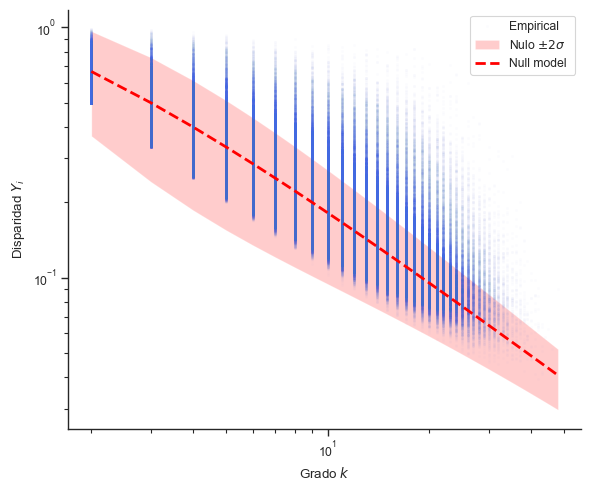

In [34]:

def calc_node_disparity(adj):
    """Calcula grado k_i y disparidad Y_i."""
    k = np.count_nonzero(adj, axis=1)
    s = np.sum(adj, axis=1)
    s_safe = np.where(s == 0, 1, s)
    
    p = adj / s_safe[:, None]
    Y = np.sum(p**2, axis=1)
    return k, Y

def null_model_stats(k):
    """Calcula la media y desviación estándar analítica del modelo nulo de Serrano."""
    Y_mean = 2.0 / (k + 1.0)
    # Varianza teórica exacta
    Y_var = (4.0 * (k - 1.0)) / ((k + 1.0)**2 * (k + 2.0) * (k + 3.0))
    Y_std = np.sqrt(np.maximum(Y_var, 0)) # Asegurar no negativos por redondeo
    return Y_mean, Y_std

# 1. Extraer k y Y de TODOS los conectomas
k_all = []
Y_all = []

# Asumiendo que connectomes_vd es tu array de (3802, 90, 90)
for adj in connectomes_vd:
    k, Y = calc_node_disparity(adj)
    mask = k > 1
    k_all.append(k[mask])
    Y_all.append(Y[mask])

# Aplanar listas en arrays 1D
k_all = np.concatenate(k_all)
Y_all = np.concatenate(Y_all)

# 2. Generar el plot (Heatmap + Null Model)
plt.figure(figsize=(6, 5))
sns.set_theme(style="ticks", context="paper")

# Scatter plot en lugar de hexbin (ideal para nubes de puntos densas)
plt.plot(k_all, Y_all, 'o', color='royalblue', alpha=0.02, markersize=2, markeredgecolor='none', label='Empirical')
plt.xscale('log')
plt.yscale('log')
# Calcular modelo nulo continuo para las líneas
k_range = np.arange(2, k_all.max() + 1)
Y_null_mean, Y_null_std = null_model_stats(k_range)

# Sombreado 2-sigma
plt.fill_between(k_range, 
                 Y_null_mean - 2*Y_null_std, 
                 Y_null_mean + 2*Y_null_std, 
                 color='red', alpha=0.2, edgecolor=None, label=r'Nulo $\pm 2\sigma$')

# Línea del modelo nulo
plt.plot(k_range, Y_null_mean, color='red', linestyle='--', linewidth=2, label='Null model ')

# Añadir la línea de promedios empíricos
#df_mean = pd.DataFrame({'k': k_all, 'Y': Y_all}).groupby('k').mean()
#plt.plot(df_mean.index, df_mean['Y'], color='black', marker='o', markersize=4, 
         #linewidth=1.5, label=r'Empírico $\langle Y \rangle$')

plt.xlabel(r'Grado $k$')
plt.ylabel(r'Disparidad $Y_i$')
sns.despine()
plt.legend()
plt.tight_layout()

plt.savefig('results/disparity/disparity_heatmap_null_model.png', dpi=300)
plt.show()

2.- Seeing that there are many nodes outside whose disparity differ from the null model, we can group those nodes by subject and calculate a mean deviation. This way we can calculate how does this deviation \Delta Y change with age. 

In [58]:
def get_global_disparity_deviation(adj):
    k, Y = calc_node_disparity(adj)
    mask = k > 1
    
    if np.sum(mask) == 0:
        return np.nan
        
    Y_null = 2.0 / (k[mask] + 1.0)
    deviation = Y[mask] - Y_null
    
    return np.mean(deviation)

deviations = [get_global_disparity_deviation(adj) for adj in connectomes_vd]

# 3. Añadir al dataframe y guardar
data['Disparity_Deviation'] = deviations

# Eliminar posibles NaNs si algún sujeto falló o tenía k<=1 en todos los nodos
data = data.dropna(subset=['Disparity_Deviation'])

data.to_csv('procdata/demographics_with_disparity_dev.csv', index=False)

3.-We send to R to calculate the residuals, just like with global disparity, and we print the smoothed curve. Run disparity_null_residuals.R

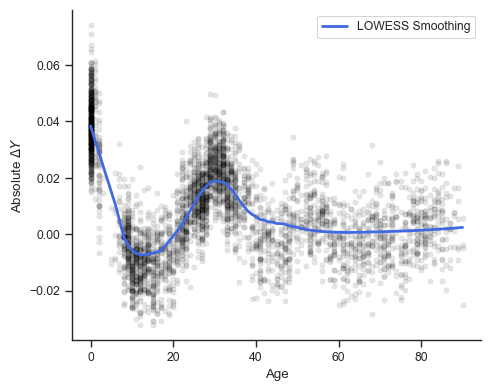

In [67]:
df_dev = pd.read_csv('procdata/disparity_residuals_dev.csv')
import statsmodels.api as sm

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_theme(style="ticks", context="paper")

# Nube de puntos
sns.scatterplot(
    data=df_dev,
    x='age',
    y='disparity_res_dev',
    alpha=0.1, color='black', s=15, edgecolor=None, ax=ax
)

# LOWESS
lowess = sm.nonparametric.lowess(df_dev['disparity_res_dev'], df_dev['age'], frac=0.3)
age_smooth, indices = np.unique(lowess[:, 0], return_index=True)
y_smooth = lowess[:, 1][indices]

ax.plot(age_smooth, y_smooth, color='royalblue', linewidth=2, label='LOWESS Smoothing')

ax.set_xlabel('Age')
ax.set_ylabel(r'Absolute $\Delta Y$')
sns.despine()
ax.legend()

plt.tight_layout()
plt.savefig('results/disparity/disparity_deviation_absolute_epochs.png', dpi=300)
plt.show()


----------------------------------------- TURNING POINTS Y DISPARIDAD POR EPOCHS --------------------------------------

1.- OPTION 1: We calculate the first derivative of the lowess regression and identify the changes in sign. 

In [79]:
df_disp_comparisson = pd.concat([df_disp['disparity_res'], df_dev['disparity_res_dev']], axis=1)
print(df_disp_comparisson.head())

   disparity_res  disparity_res_dev
0       0.212327           0.038673
1       0.198183           0.042700
2       0.179978           0.058479
3       0.183287           0.031830
4       0.209492           0.056878


Turning Points rigurosos calculados: [12. 30. 62.] años


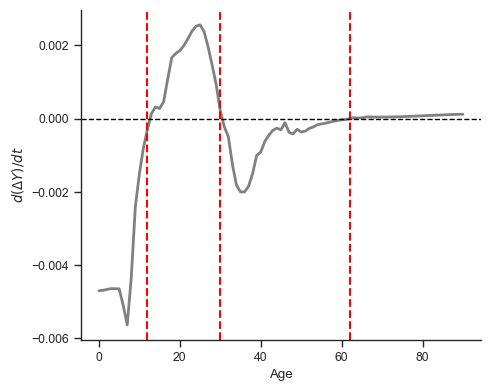

In [50]:

dy = np.gradient(y_smooth, age_smooth)
zero_crossings = np.where(np.diff(np.sign(dy)))[0]
turning_points = age_smooth[zero_crossings]
print(f"Turning Points rigurosos calculados: {np.round(turning_points, 2)} años")

fig, ax= plt.subplots(1, 1, figsize=(5, 4)) 
ax.plot(age_smooth, dy, color='gray', linewidth=2)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

for tp in turning_points:
    ax.axvline(x=tp, color='red', linestyle='--', linewidth=1.5)

ax.set_ylabel(r'$d(\Delta Y)/dt$')
ax.set_xlabel('Age')

sns.despine()
plt.tight_layout()
plt.savefig('results/disparity/disparity_deviation_derivative_epochs.png', dpi=300)
plt.show()

2.- OPTION 2: We use the turning points identified in the paper for variable density data. 

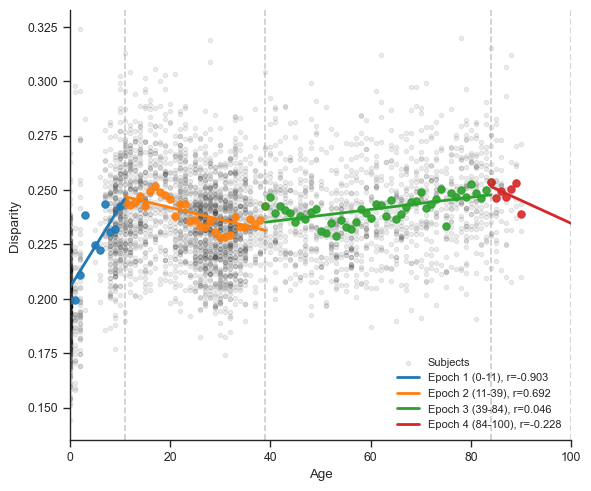

In [55]:
# 4. Plotting: raw data + age-grouped points + epoch-specific linear fits
plt.figure(figsize=(6, 5))
sns.set_theme(style="ticks", context="paper")

# Raw subject-level data (faint background)
plt.scatter(
    df_disp['age'], df_disp['disparity_res'],
    alpha=0.08, color='black', s=10, label='Subjects'
)

# Age-grouped means
df_age_grouped = df_disp.groupby('age', as_index=False)['disparity_res'].mean()

# Colors per epoch
epoch_colors = {
    '1': '#1f77b4',  # blue
    '2': '#ff7f0e',  # orange
    '3': '#2ca02c',  # green
    '4': '#d62728'   # red
}

# Variable Density turning points
epochs_vd = {
    '1': (0, 11),
    '2': (11, 39),
    '3': (39, 84),
    '4': (84, 100)
}

rows = []
for label, (start, end) in epochs_vd.items():
    window = df_dev[(df_dev['age'] >= start) & (df_dev['age'] <= end)]
    
    if len(window) > 2:
        res = pg.corr(window['age'], window['disparity_dev_res'], method='pearson')
        rows.append({
            "Epoch": label,
            "Age Range": f"{start}-{end}",
            "N": len(window),
            "r": round(res['r'].values[0], 4),
            "p-value": res['p_val'].values[0]
        })

df_results = pd.DataFrame(rows)

# Plot grouped points + fit line per epoch range
for epoch, (start, end) in epochs_vd.items():
    g = df_age_grouped[(df_age_grouped['age'] >= start) & (df_age_grouped['age'] <= end)]
    color = epoch_colors.get(epoch, 'gray')

    plt.scatter(g['age'], g['disparity_res'], color=color, s=28, alpha=0.9)

    if len(g) > 1:
        m, b = np.polyfit(g['age'], g['disparity_res'], 1)
        x_fit = np.linspace(start, end, 100)
        y_fit = m * x_fit + b

        r_val = df_results.loc[df_results['Epoch'].astype(str) == str(epoch), 'r'].values[0]
        plt.plot(x_fit, y_fit, color=color, linewidth=2,
                 label=f"Epoch {epoch} ({start}-{end}), r={r_val:.3f}")

# Epoch boundaries
for _, (start, _) in epochs_vd.items():
    if start != 0:
        plt.axvline(x=start, color='gray', linestyle='--', alpha=0.4)
plt.axvline(x=100, color='gray', linestyle='--', alpha=0.4)

plt.xlabel('Age')
plt.ylabel('Disparity ')
plt.xlim(0, 100)
plt.legend(frameon=False, fontsize=8)
sns.despine()
plt.tight_layout()

plt.savefig('results/disparity/disparity_epochs_plot.png', dpi=300)
plt.show()

In [ ]:
# ==========================================
# 3. Cálculo de Correlaciones por Época
# ==========================================
epochs_vd = {
    '1 (Infancia)': (0, 12),
    '2 (Juventud)': (12, 30),
    '3 (Adultez)': (30, 62),
    '4 (Vejez)': (62, 100)
}

rows = []
for label, (start, end) in epochs_vd.items():
    window = df_dev[(df_dev['age'] >= start) & (df_dev['age'] <= end)]
    
    if len(window) > 2:
        res = pg.corr(window['age'], window['disparity_dev_res'], method='pearson')
        rows.append({
            "Época": label,
            "Rango Edad": f"{start}-{end}",
            "N": len(window),
            "r (Pearson)": round(res['r'].values[0], 4),
            "p-valor": f"{res['p_val'].values[0]:.2e}"
        })

df_results = pd.DataFrame(rows)
print("\nCorrelaciones de ΔY con la Edad por Épocas:")
print(df_results.to_string(index=False))


Correlaciones de ΔY con la Edad por Épocas:
       Época Rango Edad    N  r (Pearson)   p-valor
1 (Infancia)       0-12  976      -0.9067  0.00e+00
2 (Juventud)      12-30 1267       0.7882 5.62e-269
 3 (Adultez)      30-62 1193      -0.5709 4.06e-104
   4 (Vejez)     62-100  560       0.2778  2.21e-11


In [ ]:
import pandas as pd
import pingouin as pg
from IPython.display import display

# Load the extracted partial residuals
df_dev = pd.read_csv('procdata/disparity_dev_residuals.csv')


display(df_results)

,Epoch,Age Range,N,r,p-value
0,1,0-11,900,-0.9035,0.000000e+00
1,2,11-39,1860,0.6916,8.154100e-265
2,3,39-84,1087,0.0457,1.317228e-01
3,4,84-100,73,-0.2278,5.256115e-02


In [52]:
# 2. Variable Density epochs (Supplementary Fig 10d)
epochs_vd = {
    '1': (0, 11),
    '2': (11, 39),
    '3': (39, 84)
}

# 3. Calculate Correlations (Subject-level)
rows = []

for label, (start, end) in epochs_vd.items():
    window = df_disp[(df_disp['age'] >= start) & (df_disp['age'] <= end)]
    
    if len(window) > 2:
        res = pg.corr(window['age'], window['disparity_res_den'], method='pearson')
        rows.append({
            "Epoch": label,
            "Age Range": f"{start}-{end}",
            "N_subjects": len(window),
            "r": round(res['r'].values[0], 4),
            "p-value": res['p_val'].values[0]
        })

df_results = pd.DataFrame(rows)
display(df_results)


KeyError: 'disparity_res_den'

----------------------------------------- SEX DIFFERENCES ------------------------------------------------------------

GAM revealed p=3.07e-12 sex difference in age-disparity relations for different sexes. We tthen fitted 2 models (for males and females) to obtain the trajectories for these subsets, creting the following Figure

<Figure size 600x500 with 0 Axes>

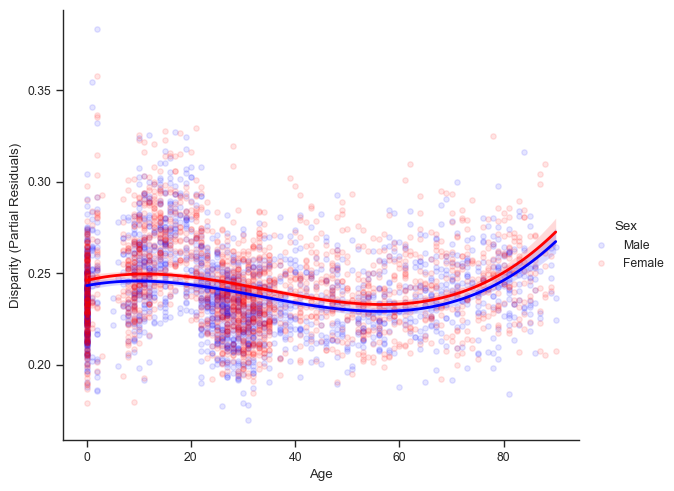

<Figure size 640x480 with 0 Axes>

In [31]:
df_sex = pd.read_csv('procdata/disparity_residuals_sex.csv')

plt.figure(figsize=(6, 5))
sns.set_theme(style="ticks", context="paper")

# Plot sex-stratified non-linear trajectories
sns.lmplot(
    data=df_sex, 
    x='age', 
    y='disparity_res', 
    hue='Sex', 
    palette={'Female': 'red', 'Male': 'blue'},
    scatter_kws={'alpha': 0.1, 's': 15}, 
    line_kws={'linewidth': 2},
    order=3, # Fits a polynomial curve to mimic the GAM spline
    height=5, 
    aspect=1.2
)

plt.xlabel('Age')
plt.ylabel('Disparity (Partial Residuals)')
sns.despine()
plt.show()
plt.savefig('results/disparity/disparity_sex_plot.png', dpi=300)

In [222]:
import pickle

data_harm.to_pickle('data_harm.pkl')
data_age_harm.to_pickle('data_age_harm.pkl')

np.savez_compressed('connectomes_harm_compressed.npz', connectomes=connectomes_harm)

-------------------------------- REGION ANALYSIS ----------------------------------------

c:\Users\Ale\Desktop\UB\NetLearn\proc_funcs.py:26: RuntimeWarning: invalid value encountered in divide
  nodal_Y = np.sum((adj / strength[:, None])**2, axis=1, where=valid[:, None])


    ROI         r         p_val   p_corrected  Significant
19  R20 -0.960312  3.011495e-14  2.710346e-12         True
69  R70 -0.912037  2.236366e-10  1.006365e-08         True
18  R19 -0.890381  2.519670e-09  6.552934e-08         True
42  R43  0.888920  2.912415e-09  6.552934e-08         True
66  R67  0.870411  1.559746e-08  2.807543e-07         True
68  R69 -0.865929  2.253632e-08  3.380448e-07         True
31  R32  0.836560  1.889535e-07  2.338063e-06         True
28  R29  0.835092  2.078278e-07  2.338063e-06         True
61  R62 -0.818103  5.873967e-07  5.873967e-06         True
43  R44  0.813703  7.555911e-07  6.800320e-06         True
37  R38  0.803047  1.354369e-06  1.108120e-05         True
67  R68  0.798970  1.677737e-06  1.258303e-05         True
34  R35 -0.777930  4.713470e-06  3.263172e-05         True
36  R37  0.774249  5.583699e-06  3.589521e-05         True
63  R64  0.760761  1.012371e-05  6.074229e-05         True


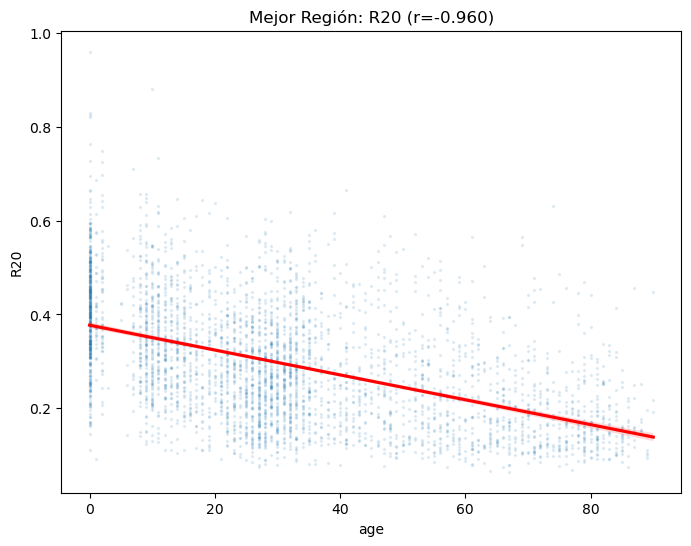

In [223]:
from proc_funcs import get_nodal_disparity_and_strength, run_roi_correlations
df_rois_disparities, df_rois_strengths = get_nodal_disparity_and_strength(connectomes_harm)

# Unimos con la edad y dataset de data_harm
df_full = pd.concat([data_harm[['age', 'dataset']], df_rois_disparities], axis=1)
#probar solo con jovenes
df_full_young = df_full[df_full['age'] <= 25]


results_young = run_roi_correlations(df_full_young, df_rois_disparities.columns, target_col='age', collapse_means=True)


winners = results_young[results_young['Significant'] == True]
print(winners.head(15))

# 7. Visualizar la mejor región
if not winners.empty:
    best_roi = winners.iloc[0]['ROI']
    r_val = winners.iloc[0]['r']
    
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df_full, x='age', y=best_roi, scatter_kws={'alpha':0.1, 's':2}, line_kws={'color':'red'})
    plt.title(f"Mejor Región: {best_roi} (r={r_val:.3f})")
    plt.show()


In [224]:
#leave last column out
df_rois_disparities.columns

Index(['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11',
       'R12', 'R13', 'R14', 'R15', 'R16', 'R17', 'R18', 'R19', 'R20', 'R21',
       'R22', 'R23', 'R24', 'R25', 'R26', 'R27', 'R28', 'R29', 'R30', 'R31',
       'R32', 'R33', 'R34', 'R35', 'R36', 'R37', 'R38', 'R39', 'R40', 'R41',
       'R42', 'R43', 'R44', 'R45', 'R46', 'R47', 'R48', 'R49', 'R50', 'R51',
       'R52', 'R53', 'R54', 'R55', 'R56', 'R57', 'R58', 'R59', 'R60', 'R61',
       'R62', 'R63', 'R64', 'R65', 'R66', 'R67', 'R68', 'R69', 'R70', 'R71',
       'R72', 'R73', 'R74', 'R75', 'R76', 'R77', 'R78', 'R79', 'R80', 'R81',
       'R82', 'R83', 'R84', 'R85', 'R86', 'R87', 'R88', 'R89', 'R90'],
      dtype='object')

✅ Atlas encontrado: ./preprocdata/aal-SPM12/aal/atlas/AAL.nii
📍 Coordenadas extraídas: 90 regiones.


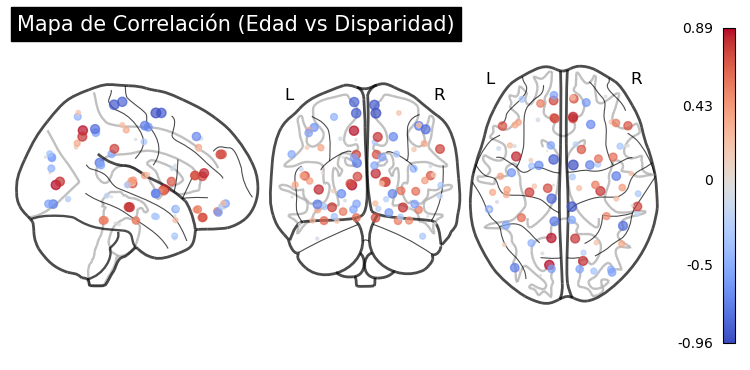

<Figure size 640x480 with 0 Axes>

In [242]:
import os
from nilearn import plotting

carpeta_destino = './preprocdata/aal-SPM12/aal/atlas/'

ruta_atlas_nii = os.path.join(carpeta_destino, 'AAL.nii')

if not os.path.exists(ruta_atlas_nii):
    # A veces está dentro de una subcarpeta, ajusta esto si es necesario
    print(f"❌ No encuentro AAL.nii en {carpeta_destino}. Revisa la carpeta.")
else:
    print(f"✅ Atlas encontrado: {ruta_atlas_nii}")

    # 4. Extraer coordenadas LOCALMENTE (Sin internet)
    # nilearn lee el archivo .nii directamente del disco duro
    coords = plotting.find_parcellation_cut_coords(ruta_atlas_nii)
    
    # 5. Recortar a las primeras 90 regiones (AAL90)
    # El archivo original tiene 116 (incluye cerebelo)
    coords_90 = coords[:90]
    
    print(f"📍 Coordenadas extraídas: {len(coords_90)} regiones.")
    
    # 6. PINTAR EL CEREBRO (Usando tu vector de correlaciones 'r')
    # Asegúrate de tener 'r_values_vector' calculado del paso anterior
    
    plotting.plot_markers(
        node_values=results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values, 
        node_coords=coords_90, 
        node_cmap='coolwarm',
        node_size=abs(results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values)*50,
        title="Mapa de Correlación (Edad vs Disparidad)"
    )
    plt.show()
    plt.savefig('results/disparity/brain_map_nodes.png', dpi=300)

    ROI         r         p_val   p_corrected  Significant
19  R20 -0.960312  3.011495e-14  2.710346e-12         True
69  R70 -0.912037  2.236366e-10  1.006365e-08         True
18  R19 -0.890381  2.519670e-09  6.552934e-08         True
42  R43  0.888920  2.912415e-09  6.552934e-08         True
66  R67  0.870411  1.559746e-08  2.807543e-07         True
68  R69 -0.865929  2.253632e-08  3.380448e-07         True
31  R32  0.836560  1.889535e-07  2.338063e-06         True
28  R29  0.835092  2.078278e-07  2.338063e-06         True
61  R62 -0.818103  5.873967e-07  5.873967e-06         True
43  R44  0.813703  7.555911e-07  6.800320e-06         True
37  R38  0.803047  1.354369e-06  1.108120e-05         True
67  R68  0.798970  1.677737e-06  1.258303e-05         True
34  R35 -0.777930  4.713470e-06  3.263172e-05         True
36  R37  0.774249  5.583699e-06  3.589521e-05         True
63  R64  0.760761  1.012371e-05  6.074229e-05         True


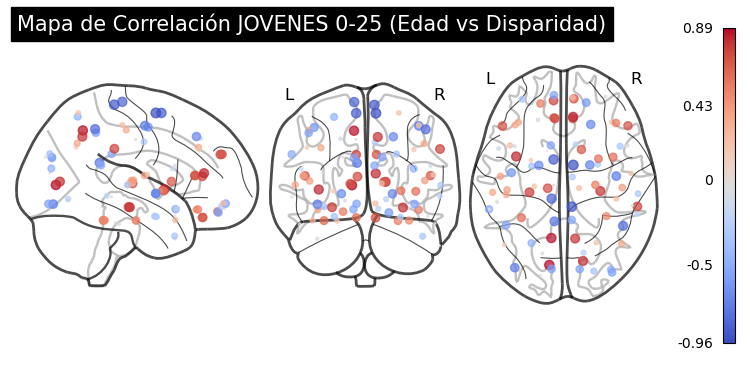

In [226]:
#probar solo con jovenes
df_full_young = df_full[df_full['age'] <= 25]
from proc_funcs import run_roi_correlations

results_young = run_roi_correlations(df_full_young, df_rois_disparities.columns, target_col='age', collapse_means=True)

winners = results_young[results_young['Significant'] == True]
print(winners.head(15))

plotting.plot_markers(
        node_values=results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values, 
        node_coords=coords_90, 
        node_cmap='coolwarm',
        node_size=abs(results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values)*50,
        title="Mapa de Correlación JOVENES 0-25 (Edad vs Disparidad)"
    )
plt.show()


📊 Analizando contribución de 90 regiones...

--- VERDAD MATEMÁTICA ---
Promedio de pendientes individuales: 0.000192
Regiones que tiran hacia ARRIBA: 51
Regiones que tiran hacia ABAJO:  39
Fuerza media hacia ARRIBA:       0.000836
Fuerza media hacia ABAJO:        -0.000651


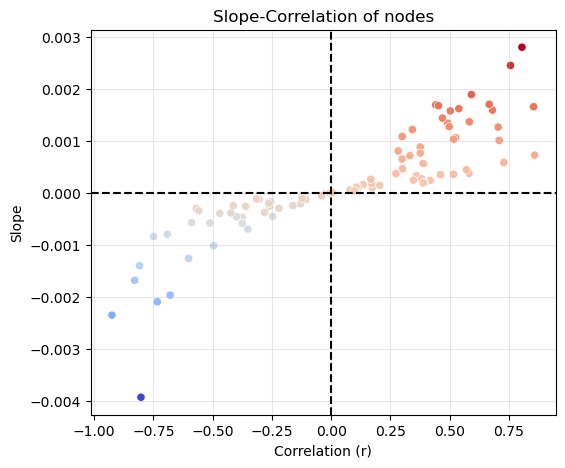

<Figure size 640x480 with 0 Axes>

In [227]:
# Función para calcular pendiente (m) y correlación (r)
def get_slope_and_corr(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return slope, r_value



# 1. Preparar datos
results_contribution = []
roi_cols = df_rois_disparities.columns.tolist()  # Use all ROI columns from df_rois

print(f"📊 Analizando contribución de {len(roi_cols)} regiones...")

# 2. Calcular Slope y R para cada región
for roi in roi_cols:
    # Usamos los datos promediados por edad como has hecho antes
    clean_data = df_full[['age', roi]].dropna().groupby('age').mean().reset_index()
    
    if len(clean_data) > 10:
        slope, r = get_slope_and_corr(clean_data['age'], clean_data[roi])
        results_contribution.append({
            'ROI': roi,
            'Slope': slope,   # Cuánto cambia Y por cada año (Magnitud)
            'Corr': r         # Qué tan consistente es (Forma)
        })

df_contrib = pd.DataFrame(results_contribution)

# 3. VERIFICACIÓN MATEMÁTICA
avg_slope = df_contrib['Slope'].mean()
print(f"\n--- VERDAD MATEMÁTICA ---")
print(f"Promedio de pendientes individuales: {avg_slope:.6f}")

# 4. ¿Quién gana? (Positivos vs Negativos)
positive_drivers = df_contrib[df_contrib['Slope'] > 0]
negative_drivers = df_contrib[df_contrib['Slope'] < 0]

print(f"Regiones que tiran hacia ARRIBA: {len(positive_drivers)}")
print(f"Regiones que tiran hacia ABAJO:  {len(negative_drivers)}")
print(f"Fuerza media hacia ARRIBA:       {positive_drivers['Slope'].mean():.6f}")
print(f"Fuerza media hacia ABAJO:        {negative_drivers['Slope'].mean():.6f}")

#export all these results to a csv
df_contrib.to_csv('results/disparity/roi_contributions.csv', index=True)


# 5. Visualización
plt.figure(figsize=(6,5))
sns.scatterplot(data=df_contrib, x='Corr', y='Slope', hue='Slope', palette='coolwarm', legend=False)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title("Slope-Correlation of nodes")
plt.xlabel("Correlation (r)")
plt.ylabel("Slope")
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig('results/disparity/slope_corr_scatter.png', dpi=300)



In [228]:
disparities_harm = calculate_disparity(connectomes_harm)

data_harm = pd.DataFrame({
    'Subject': np.arange(connectomes_harm.shape[0]),
    'Disparity_Y': disparities_harm
})

data_harm = pd.concat([data_harm, demo_harm], axis=1)


✅ Cálculo terminado. Media Global Y: 0.2415


In [229]:
#select connectomes with highest and lowest disparity and export them as .dat files

extreme_disparities = np.argsort(disparities)
print("Sujeto con menor disparidad (Y):", extreme_disparities[0]) 
print("Sujeto con mayor disparidad (Y):", extreme_disparities[-1])
#Exportar los connectomas extremos a .dat
low_disp_connectome = connectomes_harm[extreme_disparities[0]] 
high_disp_connectome = connectomes_harm[extreme_disparities[-1]] 
np.savetxt('ESNcpp/connectome_low_disparity.dat', low_disp_connectome, fmt='%.4f') 
np.savetxt('ESNcpp/connectome_high_disparity.dat', high_disp_connectome, fmt='%.4f')

Sujeto con menor disparidad (Y): 514
Sujeto con mayor disparidad (Y): 1081


In [232]:
from Graph import Graph
import networkx as nx

low_disp_connectome.dtype
low_disp_connectome.shape



# 2. Función auxiliar para convertir Matrix -> Tu Clase Graph
def matrix_to_nx(matrix, roi_labels=df_rois_disparities.columns):
    # A) Convertir numpy a NetworkX (preserva pesos en 'weight')
    nx_g = nx.from_numpy_array(matrix)
    mapping = {i: name for i, name in enumerate(roi_labels)}
    nx_g = nx.relabel_nodes(nx_g, mapping)
    
    # C) Instanciar TU clase
    return Graph(nx_g)


graph_low = matrix_to_nx(low_disp_connectome)
graph_high = matrix_to_nx(high_disp_connectome)

graph_low.describe_graph()
graph_high.describe_graph()


nx.write_gexf(graph_low.G, "ESN_Gephi/graph_low_disparity.gexf")
nx.write_gexf(graph_high.G, "ESN_Gephi/graph_high_disparity.gexf")


Graph: 90 nodes, 603 edges


Graph: 90 nodes, 465 edges



In [233]:
nx.adjacency_matrix(graph_low.G)


<Compressed Sparse Row sparse array of dtype 'float64'
	with 1206 stored elements and shape (90, 90)>

In [234]:
# Comprobación rápida: ¿Sube Y pero baja la Fuerza?
data_harm['Strength'] = [np.sum(c) for c in connectomes_harm]
print("Correlación Edad vs Strength:", stats.pearsonr(data_harm['age'], data_harm['Strength']))



Correlación Edad vs Strength: PearsonRResult(statistic=0.4246020297922468, pvalue=2.761213709154618e-166)
